# SLA Printing Membrane Defect Detection

## Install OpenCV
To install OpenCV, execute the following command.

In [ ]:
! pip install opencv-python

In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

print(cv2.__version__)

4.13.0


In the Terminal, run

In [ ]:
! python usb-cam.py

to start the camera. Save the image to the folder `img`. Then after the image of a membrane is captured, it should be cropped and modified to a rectangle for analysis. The quadrilateral `boundary` approximates the membrane region, and the function `cvt_to_59rect` turns it to into a 500x900 rectangle, as the height-width ratio of the membrane is 9:5.

Image "img\leaked.jpg" has been successfully loaded.


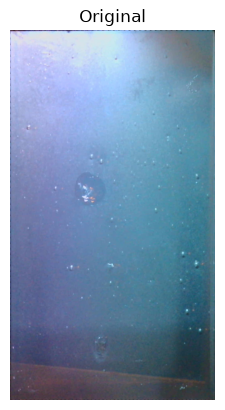

In [14]:
def cvt_to_59rect(img, boundary, size=(500, 900)):
    boundary_np = np.asarray(boundary, dtype=np.float32)
    dst = np.array([
        (0, 0),                         # TL
        (size[0] - 1, 0),               # TR
        (size[0] - 1, size[1] - 1),     # BR
        (0, size[1] - 1)                # BL
    ], dtype=np.float32)
    
    Hmat = cv2.getPerspectiveTransform(boundary_np, dst)
    rectified = cv2.warpPerspective(img, Hmat, size)
    return rectified

# ======== Modify as needed ========
input_folder = "img"
filename_wo_ext, file_ext = "leaked", "jpg"
output_folder = "output"
os.makedirs(output_folder, exist_ok=True)

filename = filename_wo_ext + '.' + file_ext
img = cv2.imread(os.path.join(input_folder, filename))
if img is None:
    raise FileNotFoundError(f"Failed to load image: \"{input_folder}/{filename}\"!")
print(f"Image \"{input_folder}/{filename}\" has been successfully loaded.")

# ======== Boundary depends on camera settings ========
boundary = np.array([
    (1543,42),
    (2510,81),
    (2483,1750),
    (1477,1696)
], dtype=np.int32)

mask = np.zeros(img.shape[:2], dtype=np.uint8)
cv2.fillPoly(mask, [boundary], 255)
img = cv2.bitwise_and(img, img, mask=mask)
img_rect = cvt_to_59rect(img, boundary)

plt.title('Original')
plt.axis('off')
plt.imshow(cv2.cvtColor(img_rect, cv2.COLOR_BGR2RGB))
plt.show()

## Filtering
Filtering is a pre-processing technique for image analysis. Blurring algorithms like `cv.blur` or `cv.GaussianBlur` reduces noise but blurs the edges. Bilater filtering `cv.bilateralFilter` does an extra job of preserving the edges. One may also use `cv.filter2D` to filter with a custom kernel. See [documentation](https://docs.opencv.org/4.13.0/d4/d86/group__imgproc__filter.html) for other filtering algorithms.

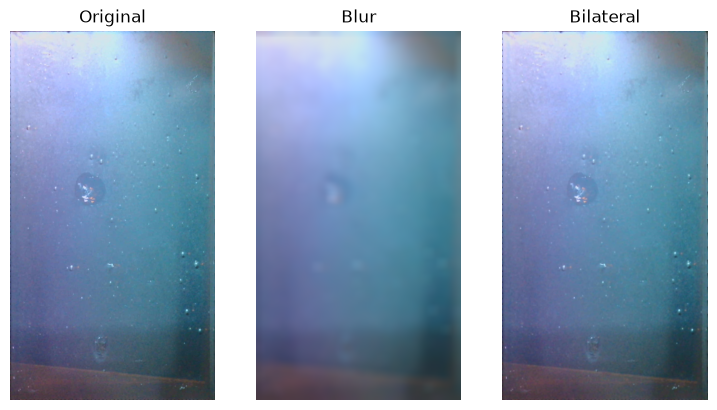

In [15]:
img_blur = cv2.GaussianBlur(img_rect, (29, 29), 10)
img_bifilter = cv2.bilateralFilter(
    img_rect,
    d=3,              # neighborhood size
    sigmaColor=75,    # color similarity
    sigmaSpace=75     # spatial similarity
)

plt.figure(figsize=(9, 5))
plt.subplot(131); plt.title('Original'); plt.axis('off'); plt.imshow(cv2.cvtColor(img_rect, cv2.COLOR_BGR2RGB))
plt.subplot(132); plt.title('Blur'); plt.axis('off'); plt.imshow(cv2.cvtColor(img_blur, cv2.COLOR_BGR2RGB))
plt.subplot(133); plt.title('Bilateral'); plt.axis('off'); plt.imshow(cv2.cvtColor(img_bifilter, cv2.COLOR_BGR2RGB))
plt.show()

## Thresholding
Thresholding can identify exceptionally bright or dark regions, but it is sensitive to shadows. For more information see the [documentation](https://docs.opencv.org/4.13.0/d7/d1b/group__imgproc__misc.html).

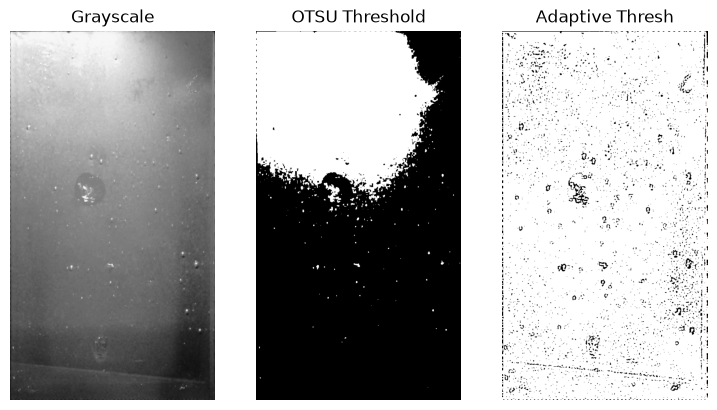

In [ ]:
# Thresholding

img_gray = cv2.cvtColor(img_rect, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(img_gray, (5, 5), 0)
_, img_thresh = cv2.threshold(
    img_gray,      # input array
    0,             # set to 0 bc no longer useful as otsu is used
    255,           # maxval for THRESH_BINARY
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
    # THRESH_BINARY: binary thresholding is used
    # THRESH_OTSU is combined to indicate that optimal threshold value is chosen by the OTSU algo.
)
# cv2.THRESH_OTSU solves the shadowing problem
img_thresh_adp = cv2.adaptiveThreshold(
    blur,                        # input array
    255,                         # maxval for THRESH_BINARY
    cv2.ADAPTIVE_THRESH_MEAN_C,  # specifies that threshold = avg within block - C
    cv2.THRESH_BINARY,           # binary thresholding is used
    5,                           # block size (= 3, 5, 7, ...)
    2                            # C
)

plt.figure(figsize=(9, 5))
plt.subplot(131); plt.axis('off'); plt.imshow(img_gray, cmap='gray'); plt.title('Grayscale')
plt.subplot(132); plt.axis('off'); plt.imshow(img_thresh, cmap='gray'); plt.title('OTSU Threshold')
plt.subplot(133); plt.axis('off'); plt.imshow(img_thresh_adp, cmap='gray'); plt.title('Adaptive Thresh')
plt.show()

## Edge Detection
Edge detection is crucial for identification of membrane defects. Almost every edge detection algorithm relies on pixel gradients. Among all algorithms, Canny is chosen because of its high accuracy, good localization, and robustness to noise ([read more](https://docs.opencv.org/4.13.0/da/d22/tutorial_py_canny.html)). In the function
```
cv.Canny(image, threshold1, threshold2, edges=None, apertureSize=3, L2gradient=False) -> edges
```
parameters
- `image` is the input array
- `threshold1` is the weak edge threshold
- `threshold2` is the strong edge threshold
- `edge` is a reference to the output array; in Python it is typically set to `None`
- `apertureSize` is the aperture size for the Sobel operator
- `L2gradient` indicates whether the L2-norm, defined by 
  $$ \sqrt{\left( \frac{\partial I}{\partial x} \right)^2 + \left( \frac{\partial I}{\partial y} \right)^2} $$
  where $I(x,y)$ is the image intensity function, should be used.

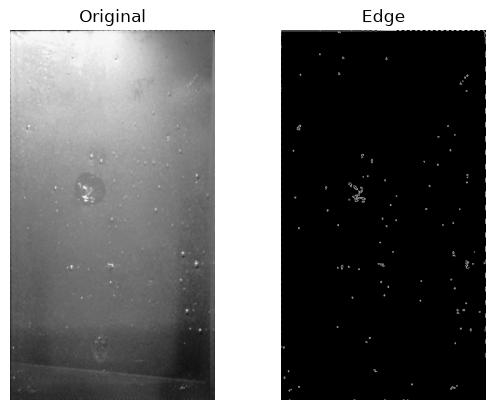

In [18]:
img_gray = cv2.cvtColor(img_rect, cv2.COLOR_BGR2GRAY)
img_canny = cv2.Canny(
    img_rect,
    100,              # weak edge thresh
    200,              # strong edge thresh
    apertureSize=3    # aperture size
)

plt.subplot(121); plt.title('Original'); plt.axis('off'); plt.imshow(img_gray, cmap='gray')
plt.subplot(122); plt.title('Edge'); plt.axis('off'); plt.imshow(img_canny, cmap='gray')
plt.show()

## Defect Classification
Finally, it is time to combine the image processing techniques. Geometry features of a "contour" (continuous edge) used to classify whether it is a hole or wrinkle.

In [25]:
def classify_contours(img, boundary=np.array([[0,0], [900,0], [900,500], [0,500]])):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 40, 200)
    contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

    result = img.copy()
    for cnt in contours:
        area, perimeter = cv2.contourArea(cnt), cv2.arcLength(cnt, True)
        rRect = cv2.minAreaRect(cnt)
        center, size, angle = rRect

        if area < 1 or perimeter < 10:
            continue

        if area > 1000 or perimeter > 1000:
            continue

        center_pt = (int(center[0]), int(center[1]))
        dist = cv2.pointPolygonTest(boundary, center_pt, True)
        if dist <= 10:
            continue

        h, w = size
        aspect_ratio = max(w, h) / (min(w, h) + 1e-5)
        circularity = 4 * np.pi * area / (perimeter**2 + 1e-5)

        # --- edge density in region ---
        box = cv2.boxPoints(rRect)
        box = np.int32(box)
        roi = edges[box[:, 1].min():box[:, 1].max(), box[:, 0].min():box[:, 0].max()]
        edge_density = np.sum(roi > 0) / (roi.shape[0] * roi.shape[1] + 1e-5)

        if circularity > 0.5 and aspect_ratio < 2:
            color = (0, 255, 0)

        # WRINKLE: elongated or dense edges
        elif aspect_ratio > 3 or edge_density > 0.2:
            color = (255, 0, 0)

        # UNIDENTIFIED
        else:
            color = (0, 255, 255)

        # --- draw result ---
        cv2.drawContours(result, [box], -1, color, 2)

    print("Color map:")
    print("  - GREEN:  hole")
    print("  - BLUE:   wrinkle")
    print("  - YELLOW: unknown")
    return result

Color map:
  - GREEN:  hole
  - BLUE:   wrinkle
  - YELLOW: unknown


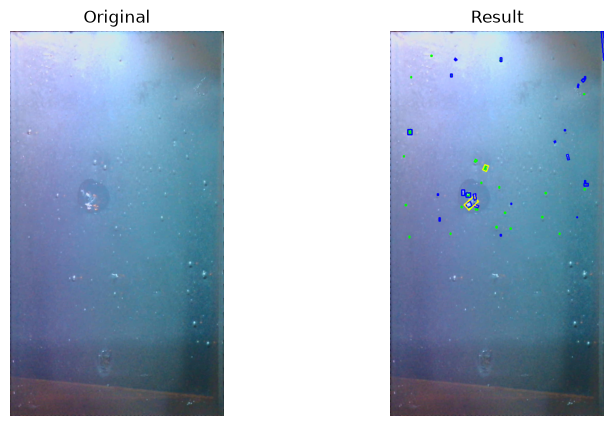

In [26]:
ret_rect = classify_contours(img_rect)
# ret_rect = cvt_to_59rect(ret, boundary)

img_rgb = cv2.cvtColor(img_rect, cv2.COLOR_BGR2RGB)
ret_rgb = cv2.cvtColor(ret_rect, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(9, 5))
plt.subplot(121); plt.title('Original'); plt.axis('off'); plt.imshow(img_rgb)
plt.subplot(122); plt.title('Result'); plt.axis('off'); plt.imshow(ret_rgb)
plt.show()